You have been hired by a rookie movie producer to help him decide what type of movies to produce and which actors to cast. You have to back your recommendations based on thorough analysis of the data he shared with you which has the list of 3000 movies and the corresponding details.

 As a data scientist, you have to first explore the data and check its sanity.

Further, you have to answer the following questions:
1. Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.
2. This data has information about movies made in different languages. Which language has the highest average ROI (return on investment)?
3. Find out the unique genres of movies in this dataset.
4. Make a table of all the producers and directors of each movie. Find the top 3 producers who have produced movies with the highest average RoI?
5. Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.
6. Top 3 directors prefer which actors the most?

In [1]:
import pandas as pd
import numpy as np
import ast

In [2]:
df = pd.read_csv('imdb_data (1).csv')

In [3]:
df.head(5)

We can observe that details like genre, actors, directors, producers name are in form of other data types in different columns so we will extract them first and create a new column for each for easy future accessing

In [4]:
df['genre_list'] = df['genres'].apply(lambda x: [d['name'] for d in ast.literal_eval(x)]
                                      if isinstance(x, str) and x != 'nan' else [])
df['actors'] = df['cast'].apply(lambda x: [d['name'] for d in ast.literal_eval(x)]
                                    if isinstance(x, str) and x != 'nan' else [])
df['directors'] = df['crew'].apply(lambda x: [d['name'] for d in ast.literal_eval(x)
                            if d.get('job') == 'Director'] if isinstance(x, str) and x != 'nan' else [])
df['producers'] = df['crew'].apply(lambda x: [d['name'] for d in ast.literal_eval(x)
                            if d.get('job') == 'Producer'] if isinstance(x, str) and x != 'nan' else [])

## 1. Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.

In [5]:
df['profit'] = df['revenue'] - df['budget']
highest_profit_idx = df['profit'].idxmax()
highest_profit_movie = df.loc[highest_profit_idx]
print("Highest Profit Movie Details:")
print(highest_profit_movie[['title', 'profit', 'directors', 'actors']])

Highest Profit Movie Details:
title                                                Furious 7
profit                                              1316249360
directors                                          [James Wan]
actors       [Vin Diesel, Paul Walker, Dwayne Johnson, Mich...


## 2. This data has information about movies made in different languages. Which language has the highest average ROI (return on investment)?

In [6]:
df['roi'] = np.where(df['budget'] > 0, df['profit'] / df['budget'], np.nan)
language_roi = df.groupby('original_language')['roi'].mean().sort_values(ascending=False).head(1)
print("Language with Highest Average ROI:")
print(language_roi)

Language with Highest Average ROI:
original_language
ko    381794.102281


## 3. Find out the unique genres of movies in this dataset.

In [7]:
unique_genres=set()
for g_list in df['genre_list']:
  for genre in g_list:
    unique_genres.add(genre)
print("Unique Genres:")
print(unique_genres)

Unique Genres:
{'TV Movie', 'Music', 'Drama', 'Comedy', 'Documentary', 'War', 'Foreign', 'Horror', 'History', 'Fantasy', 'Crime', 'Romance', 'Action', 'Thriller', 'Adventure', 'Western', 'Mystery', 'Animation', 'Family', 'Science Fiction'}


## 4. Make a table of all the producers and directors of each movie. Find the top 3 producers who have produced movies with the highest average RoI?

In [8]:
prod_dir_table = df[['title', 'producers', 'directors']]
print("Producer Director Table:")
print(prod_dir_table.head())

Producer Director Table:
                                      title                                                      producers          directors
0                    Hot Tub Time Machine 2                                                 [Andrew Panay]       [Steve Pink]
1  The Princess Diaries 2: Royal Engagement          [Whitney Houston, Mario Iscovich, Debra Martin Chase]   [Garry Marshall]
2                                  Whiplash  [David Lancaster, Michel Litvak, Jason Blum, Helen Estabrook]  [Damien Chazelle]
3                                   Kahaani                                                  [Sujoy Ghosh]      [Sujoy Ghosh]
4                                Marine Boy                                                             []   [Jong-seok Yoon]


In [9]:
exploded_producers = df.explode('producers')
top_3_producers = exploded_producers.groupby('producers')['roi'].mean().sort_values(ascending=False).head(3)
print("Top 3 Producers who have produced movies with the highest average RoI:")
print(top_3_producers)

Top 3 Producers who have produced movies with the highest average RoI:
producers
Ji Sang-yong    4197475.625
Lee Eun-ha      4197475.625
Jang Jin        4197475.625


## 5. Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.

In [10]:
exploded_actors = df.explode('actors')
top_actor = exploded_actors['actors'].value_counts().idxmax()
actor_data = df[df['actors'].apply(lambda x: top_actor in x)]
print("Actor who have acted in the most number of movies: ",top_actor)
print("Number of movies: ",actor_data.shape[0])
print("Movies: ")
print(actor_data['title'].head(5))
print("Total profit in all movies of this actor: ",actor_data['profit'].sum())

Actor who have acted in the most number of movies:  Samuel L. Jackson
Number of movies:  30
Movies: 
29                                    Changing Lanes
47                                 The Hateful Eight
642                                Coming to America
689     Star Wars: Episode III - Revenge of the Sith
1055                                    Meeting Evil
Total profit in all movies of this actor:  6795301670


## 6. Top 3 directors prefer which actors the most?

In [11]:
#assuming ranking of directors is based on number of movies directed

In [12]:
exploded_directors=df.explode('directors')
top_3_directors = exploded_directors['directors'].value_counts().head(3).index.tolist()
print("Top 3 Directors' most preferred(casted) actors:")
for director in top_3_directors:
    dir_movies = df[df['directors'].apply(lambda x: director in x)]
    dir_pref_actor = dir_movies.explode('actors')['actors'].value_counts().idxmax()
    print("Director: ",director,"  => Preferred Actor: ",dir_pref_actor)

Top 3 Directors' most preferred(casted) actors:
Director:  Ron Howard   => Preferred Actor:  Clint Howard
Director:  Clint Eastwood   => Preferred Actor:  Clint Eastwood
Director:  Steven Spielberg   => Preferred Actor:  Harrison Ford


# **Visualisation using matplotlib and seaborn**

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

### Top 10 movie genres (barplot)

In [14]:
exploded_genres=df.explode('genre_list')
genre_counts = exploded_genres['genre_list'].value_counts().head(10)
print(genre_counts)

genre_list
Drama              1531
Comedy             1028
Thriller            789
Action              741
Romance             571
Crime               469
Adventure           439
Horror              301
Science Fiction     290
Family              260


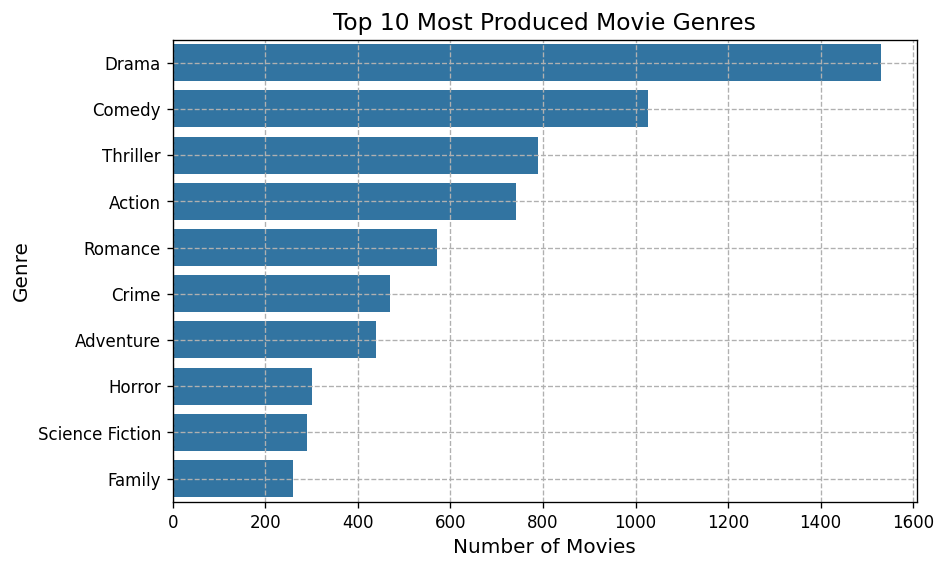

In [15]:
plt.figure()
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Top 10 Most Produced Movie Genres', fontsize=14)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.grid(linestyle='--')
plt.show()

### Budget vs Revenue (Scatter Plot)

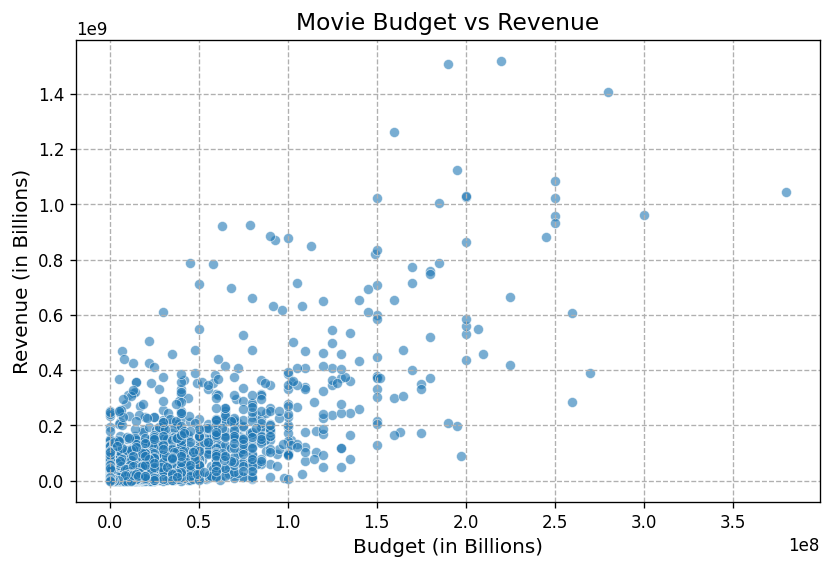

In [16]:
plt.figure()
sns.scatterplot(data=df, x='budget', y='revenue', alpha=0.6)
plt.title('Movie Budget vs Revenue', fontsize=14)
plt.xlabel('Budget (in Billions)', fontsize=12)
plt.ylabel('Revenue (in Billions)', fontsize=12)
plt.grid(linestyle='--')
plt.show()

## Box Plot of Movie Runtimes

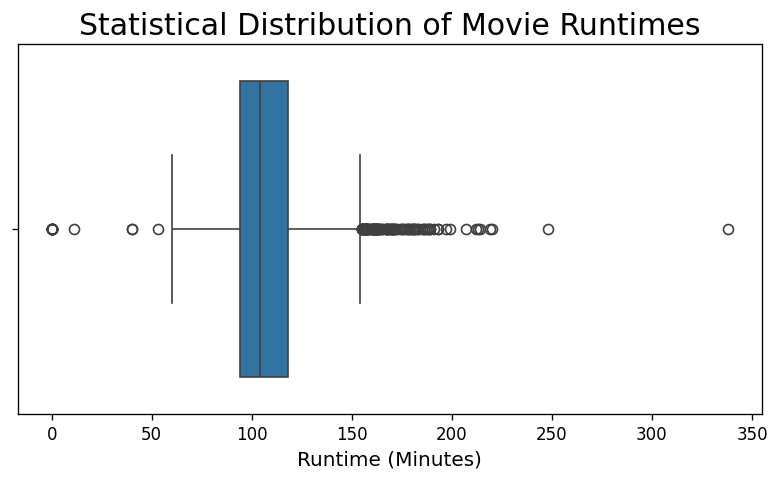

In [17]:
runtime_data = df['runtime'].dropna()
plt.figure()
sns.boxplot(x=runtime_data)
plt.title('Statistical Distribution of Movie Runtimes', fontsize=18)
plt.xlabel('Runtime (Minutes)', fontsize=12)
plt.show()